# Analiza danych tekstowych, porównanie technik obróbki tekstu w kontekście klasyfikacji

Wykonanie analizy oraz stworzenie modeli klasyfikacji tekstu w kontekście analizy sentymentu na podstawie danych Human Stress ([Link do zbioru danych w serwisie Kaggle](https://www.kaggle.com/datasets/kreeshrajani/human-stress-prediction)). Wykorzystanie różnych technik przetwarzania tekstu oraz porównanie ich skuteczności w klasyfikacji sentymentu.

In [26]:
import pandas as pd

df_train = pd.read_csv("../../data/mental_health_data.csv", index_col=0)

In [27]:
print(f"== DF TRAIN COLUMNS ==")
print(f"train: {df_train.columns.to_list()}\n")
print(f"== DF TRAIN SHAPE ==")
print(f"train: {df_train.shape}\n")

== DF TRAIN COLUMNS ==
train: ['statement', 'status']

== DF TRAIN SHAPE ==
train: (53043, 2)



Text(0, 0.5, 'Count')

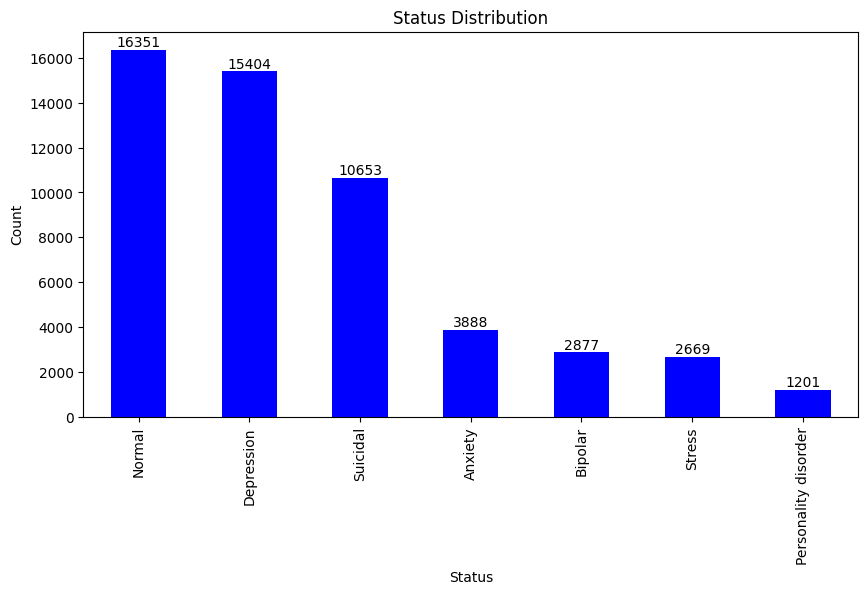

In [28]:
import matplotlib.pyplot as plt

df = df_train
data = df_train['status'].value_counts()

plt.plot()
data.plot(kind='bar', color='blue', figsize=(10, 5))
for i, v in enumerate(data):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=10)
plt.title('Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')

<Axes: >

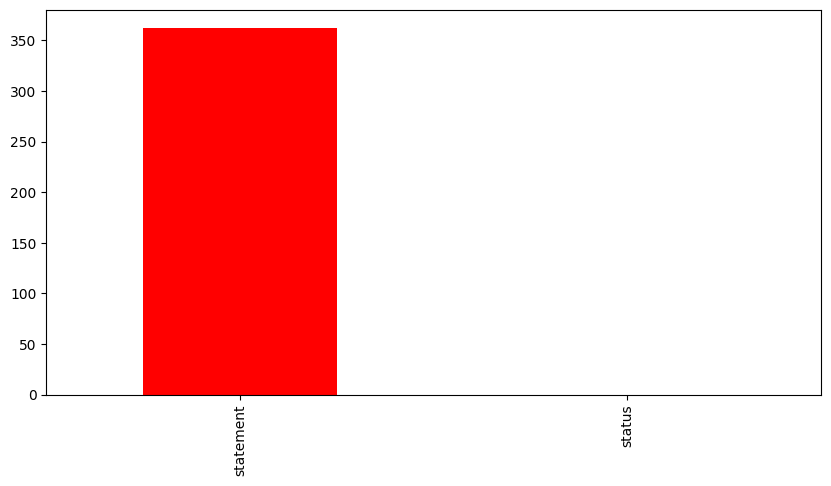

In [29]:
df.isna().sum().plot(kind='bar', color='red', figsize=(10, 5))

Na powyższym wykresie widzimy, że w danych są braki. W porównaniu do całości zbioru, który liczy ponad 50000 rekordów mamy lekko ponad 350 braków. 

In [30]:
df.isna().sum()[0]/len(df) * 100

C:\Users\admin\AppData\Local\Temp\ipykernel_23700\3288132808.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.isna().sum()[0]/len(df) * 100


0.6824651697679242

Braków jest 0.68% stąd usuniemy je ze zbioru.

In [31]:
df = df[~df['statement'].isna()]

W tym zbiorze danych mamy bardzo nierównomierny rozkład cechy `Status`. Początkowo decydujemy się go zostawić, ponieważ może być to naturalne podejście, lecz zastosowane zostanie także łączenie poziomów.

## Preprocesowanie danych

In [32]:
lst = df['statement'][:3].tolist()
for l in lst:
    print(f"{l}\n")

oh my gosh

trouble sleeping, confused mind, restless heart. All out of tune

All wrong, back off dear, forward doubt. Stay in a restless and restless place



Na pierwszy rzut oka nie powinny znajdować się tu błędy językowe, błędy w pisowni czy takie specjalne części zdania jak nazwy własne/nicki użytkowników/linki.

### Sprowadzenie tesktu do małych liter

In [33]:
print(f"== BEFORE LOWER ==\n{df['statement'][:3]}\n")
df['processed_statement'] = df['statement'].str.lower()
print(f"== AFTER LOWER ==\n{df['processed_statement'][:3]}\n")

== BEFORE LOWER ==
0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    All wrong, back off dear, forward doubt. Stay ...
Name: statement, dtype: object

== AFTER LOWER ==
0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    all wrong, back off dear, forward doubt. stay ...
Name: processed_statement, dtype: object



C:\Users\admin\AppData\Local\Temp\ipykernel_23700\1165085094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['processed_statement'] = df['statement'].str.lower()


### Usunięcie oznaczeń i linków do stron internetowych

In [34]:
def remove_usernames_and_links(text):
    if not isinstance(text, str):
        return text
    text = ' '.join([word for word in text.split() if not word.startswith('@')])
    text = ' '.join([word for word in text.split() if not '@' in word])
    text = ' '.join([word for word in text.split() if not word.startswith('http')])
    return text

In [35]:
counter = 0

for i, row in df.iterrows():
    if type(row['processed_statement']) is not str:
        print(f"Row {i} is not a string")
        continue
    if 'http' in row['processed_statement']:
        print(f"Row {i} contains URL")
        print(f'\t Message: {row["processed_statement"]}')
        counter += 1
        
print(f"== Detected URLs in dataset {counter}/{len(df)} ==\n")

Row 4786 contains URL
	 Message: issue number on may 10, 2021.pasaran dewata..result : 5946.shio: naga..greetings jp paus!!!!..link : https://138.197.167.100/.#bersama4d #togeldewata
Row 30104 contains URL
	 Message: most diagnoses, except those relating to the endangerment of children, are welcome. this is a first person group, so you need to be the person with a disorder to participate. to join visit our site [https://thehaven.support](https://thehaven.support/) or check out our instagram: <url> we believe we are stronger together, which is why peer support is so helpful and important. care when you need it; care for others when you can. \-zen
Row 33929 contains URL
	 Message: finally getting better. my anxiety was to a point where every few days i was posting in the sub and r/anxiety. i suspect my anxiety was worsened by being on antibiotics, at pretty heavy doses destroying my gut bacteria, and a hormone imbalance from going on and off of birth control after 5 years of being on it 

In [36]:
print(f"== BEFORE NICKS AND LINKS ==\n{df['processed_statement'][13:17]}\n")
df['processed_statement'] = df['processed_statement'].apply(remove_usernames_and_links)
print(f"== AFTER NICKS AND LINKS ==\n{df['processed_statement'][13:17]}\n")

== BEFORE NICKS AND LINKS ==
13                           because this worry is you.
14    sometimes it's your own thoughts that make you...
15    every time i wake up, i'm definitely nervous a...
16    i can only hope, even though i'm worried if it...
Name: processed_statement, dtype: object

== AFTER NICKS AND LINKS ==
13                           because this worry is you.
14    sometimes it's your own thoughts that make you...
15    every time i wake up, i'm definitely nervous a...
16    i can only hope, even though i'm worried if it...
Name: processed_statement, dtype: object



C:\Users\admin\AppData\Local\Temp\ipykernel_23700\707865505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['processed_statement'] = df['processed_statement'].apply(remove_usernames_and_links)


Widzimy, że usunięto jednak aż 1080 linków. Widzimy też, że wiele rekordów jest odbieranych jako float. Poniżej sprawdzimy jak wyglądają poszczególne rekordy.

### Usunięcie słów stopu

In [37]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
from nltk.corpus import stopwords
stop_words = list(stopwords.words('english'))

In [39]:
print(f"== ENGLISH STOPWORDS ==\n{len(stop_words)}\n{stop_words[:10]}\n")

== ENGLISH STOPWORDS ==
198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']



In [40]:
print(f"== BEFORE STOPWORDS ==\n{df['processed_statement'][:3]}\n")
df['processed_statement'] = df['processed_statement'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
print(f"== AFTER STOPWORDS ==\n{df['processed_statement'][:3]}\n")

== BEFORE STOPWORDS ==
0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    all wrong, back off dear, forward doubt. stay ...
Name: processed_statement, dtype: object

== AFTER STOPWORDS ==
0                                              oh gosh
1    trouble sleeping, confused mind, restless hear...
2    wrong, back dear, forward doubt. stay restless...
Name: processed_statement, dtype: object



C:\Users\admin\AppData\Local\Temp\ipykernel_23700\1132101765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['processed_statement'] = df['processed_statement'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))


### Usunięcie znaków interpunkcyjnych i cyfr

In [41]:
import re

def remove_numbers(text):
    result = re.sub(r'\d+', '', text)
    return result

def remove_punctuation(text):
    result = re.sub(r'[^\w\s]', '', text)
    return result

In [42]:
print(f"== BEFORE NUMBERS AND PUNCTUATION ==\n{df['processed_statement'][:3]}\n")
df['processed_statement'] = df['processed_statement'].apply(remove_numbers)
df['processed_statement'] = df['processed_statement'].apply(remove_punctuation)
print(f"== AFTER NUMBERS AND PUNCTUATION ==\n{df['processed_statement'][:3]}\n")

== BEFORE NUMBERS AND PUNCTUATION ==
0                                              oh gosh
1    trouble sleeping, confused mind, restless hear...
2    wrong, back dear, forward doubt. stay restless...
Name: processed_statement, dtype: object



C:\Users\admin\AppData\Local\Temp\ipykernel_23700\2914130821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['processed_statement'] = df['processed_statement'].apply(remove_numbers)


== AFTER NUMBERS AND PUNCTUATION ==
0                                              oh gosh
1    trouble sleeping confused mind restless heart ...
2    wrong back dear forward doubt stay restless re...
Name: processed_statement, dtype: object



C:\Users\admin\AppData\Local\Temp\ipykernel_23700\2914130821.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['processed_statement'] = df['processed_statement'].apply(remove_punctuation)


### Weryfikacja zbioru po przeczyszczeniu

In [43]:
print(f"Total number of rows in the dataset: {df.shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['processed_statement'] == ''].shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['processed_statement'] == ' '].shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['processed_statement'] == None].shape[0]}")

Total number of rows in the dataset: 52681
Total number of rows with empty tweets: 24
Total number of rows with empty tweets: 1
Total number of rows with empty tweets: 0


Widzimy łącznie 25 rekordy, które podczas czyszczenia zbioru danych ze słów stopu, znaków interpunkcyjnych i linków zostatły puste

In [45]:
idx = df[df['processed_statement'] == ''].index
idx2 = df[df['processed_statement'] == ' '].index
    
print(f"{df['status'].iloc[idx].value_counts()}")    
print(f"{df['status'].iloc[idx2].value_counts()}")    

status
Normal        21
Depression     2
Suicidal       1
Name: count, dtype: int64
status
Depression    1
Name: count, dtype: int64


Rekordy te mają kategorię głównie `Normal` stąd dodanie pustych rekordów zaklasyfikowanych jako `Normal` może wprowadzać szum.

In [46]:
print(f"== BEFORE DELETE RECORDS ==\t{df.shape[0]}")
df = df[df['processed_statement'] != '']
df = df[df['processed_statement'] != ' ']
print(f"== AFTER DELETE RECORDS ==\t{df.shape[0]}")

== BEFORE DELETE RECORDS ==	52681
== AFTER DELETE RECORDS ==	52656


### Lematyzacja 

Jest to proces sprowadzania słów do ich podstawowych form. Do tego celu możemy wykorzystać dwie biblioteki - NLTK oraz SpaCy. 

In [47]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [48]:
!python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load('en_core_web_sm')


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------- ----------------------- 5.2/12.8 MB 35.3 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 42.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [49]:
print(f"== BEFORE LEMMATIZATION ==\n{df['processed_statement'][:3]}\n")
df['NLTKProcessed'] = df['processed_statement'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df['SpacyProcessed'] = df['processed_statement'].apply(lambda x: ' '.join([token.lemma_ for token in nlp(x)]))
print(f"== AFTER LEMMATIZATION (NLTK)==\n{df['NLTKProcessed'][:3]}\n")
print(f"== AFTER LEMMATIZATION (SPACY)==\n{df['SpacyProcessed'][:3]}\n")

== BEFORE LEMMATIZATION ==
0                                              oh gosh
1    trouble sleeping confused mind restless heart ...
2    wrong back dear forward doubt stay restless re...
Name: processed_statement, dtype: object

== AFTER LEMMATIZATION (NLTK)==
0                                              oh gosh
1    trouble sleeping confused mind restless heart ...
2    wrong back dear forward doubt stay restless re...
Name: NLTKProcessed, dtype: object

== AFTER LEMMATIZATION (SPACY)==
0                                              oh gosh
1      trouble sleep confused mind restless heart tune
2    wrong back dear forward doubt stay restless re...
Name: SpacyProcessed, dtype: object



Możemy także sprawdzić jak różnią się od siebie oba zbiory. 

In [50]:
df.columns

Index(['statement', 'status', 'processed_statement', 'NLTKProcessed',
       'SpacyProcessed'],
      dtype='object')

In [51]:
differences = df[df['NLTKProcessed'] != df['SpacyProcessed']]
print(f"== DIFFERENT RECORDS ==\nLiczba różniących się wierszy: {len(differences)}, wszystkich jest: {len(df)}\n")

== DIFFERENT RECORDS ==
Liczba różniących się wierszy: 43701, wszystkich jest: 52656



In [52]:
def compare_words(nltk_text, spacy_text):
    nltk_words = set(nltk_text.split())
    spacy_words = set(spacy_text.split())
    return {
        'only_in_nltk': nltk_words - spacy_words,
        'only_in_spacy': spacy_words - nltk_words
    }

nltk_words = set(' '.join(df['NLTKProcessed']).split())
spacy_words = set(' '.join(df['SpacyProcessed']).split())

only_in_nltk = nltk_words - spacy_words
only_in_spacy = spacy_words - nltk_words

total_unique_words = len(nltk_words.union(spacy_words))
different_words = len(only_in_nltk) + len(only_in_spacy)
percentage_difference = (different_words / total_unique_words) * 100

print(f"Liczba unikalnych słów w NLTK: {len(nltk_words)}")
print(f"Liczba unikalnych słów w SpaCy: {len(spacy_words)}")
print(f"Liczba słów różniących się między NLTK i SpaCy: {different_words}")
print(f"Procent różnic na poziomie słów: {percentage_difference:.2f}%")

Liczba unikalnych słów w NLTK: 69856
Liczba unikalnych słów w SpaCy: 66498
Liczba słów różniących się między NLTK i SpaCy: 15820
Procent różnic na poziomie słów: 20.79%


Widzimy, że na zbiorze niemalże 5572 rekordów oba lematyzatory różnią się od siebie w sposobie sprowadzania słów do podstawowej postaci. Stąd też wytrenowane modele będziemy weryfikować uwzględniając, który lematyzator został użyty.

W przypadku analizy zbioru Corona widzieliśmy, że ten błąd (różnice słów na tych samych miejscach w rekordach) była większa o około 8 punktów procentowych).

### Stematyzacja

Stemming to proces obcinania końcówek słów sprowadzając je do rdzenia. Nie bierze przy tym pod uwagę, czy takie słowo istnieje czy też nie. Tym właśnie różni się od lematyzacji, która sprowadza do podstawowej formy, ale to słowo jest w słowniku. 

In [53]:
from nltk.stem import PorterStemmer 
stemmer = PorterStemmer()

In [54]:
print(f"== BEFORE STEMMING ==\n{df['processed_statement'][:3]}\n")
df['Stemmed'] = df['processed_statement'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))
print(f"== AFTER STEMMING ==\n{df['Stemmed'][:3]}\n")

== BEFORE STEMMING ==
0                                              oh gosh
1    trouble sleeping confused mind restless heart ...
2    wrong back dear forward doubt stay restless re...
Name: processed_statement, dtype: object

== AFTER STEMMING ==
0                                              oh gosh
1         troubl sleep confus mind restless heart tune
2    wrong back dear forward doubt stay restless re...
Name: Stemmed, dtype: object



## Modele ML

### Przygotowanie danych do modeli

In [61]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import time

In [62]:
# accuracy, precision, recall, f1-score
eval_metrics = {
    'NLTK': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    }, 
    'SpaCy': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Stemmed': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Processed': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'ProcessedTextBlob': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Original': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    }
}

In [57]:
print(list(df.columns))

texts_nltk = df['NLTKProcessed'].tolist()           # użyto NLTK do lematyzacji
texts_spacy = df['SpacyProcessed'].tolist()         # użyto Spacy do lematyzacji
texts_stemmed = df['Stemmed'].tolist()              # użyto stemmingu
texts_processed = df['processed_statement'].tolist()     # użyto przetworzonego tekstu bez lematyzacji i stemmingu
texts = df['statement'].tolist()                # użyto oryginalnego tekstu
labels = df['status'].tolist()

['statement', 'status', 'processed_statement', 'NLTKProcessed', 'SpacyProcessed', 'Stemmed']


In [63]:
vectorizer = TfidfVectorizer(max_features=5000)  # np. do 5000 słów
X_nltk = vectorizer.fit_transform(texts_nltk)
X_spacy = vectorizer.fit_transform(texts_spacy)
X_stemmed = vectorizer.fit_transform(texts_stemmed)
X_processed = vectorizer.fit_transform(texts_processed)
X = vectorizer.fit_transform(texts)
y = labels

In [64]:
X_train_nltk, X_test_nltk, y_train_nltk, y_test_nltk = train_test_split(X_nltk, y, test_size=0.25, random_state=42)
X_train_spacy, X_test_spacy, y_train_spacy, y_test_spacy = train_test_split(X_spacy, y, test_size=0.25, random_state=42)
X_train_stemmed, X_test_stemmed, y_train_stemmed, y_test_stemmed = train_test_split(X_stemmed, y, test_size=0.25, random_state=42)
X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(X_processed, y, test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_trains = {
    'NLTK': X_train_nltk,
    'SpaCy': X_train_spacy,
    'Stemmed': X_train_stemmed,
    'Processed': X_train_processed,
    'Original': X_train
}
X_tests = {
    'NLTK': X_test_nltk,
    'SpaCy': X_test_spacy,
    'Stemmed': X_test_stemmed,
    'Processed': X_test_processed,
    'Original': X_test
}
y_trains = {
    'NLTK': y_train_nltk,
    'SpaCy': y_train_spacy,
    'Stemmed': y_train_stemmed,
    'Processed': y_train_processed,
    'Original': y_train
}
y_tests = {
    'NLTK': y_test_nltk,
    'SpaCy': y_test_spacy,
    'Stemmed': y_test_stemmed,
    'Processed': y_test_processed,
    'Original': y_test,
}

#### Sprawdzenie rozkładu klas 

In [66]:
from collections import Counter

def print_class_distribution(y, label):
    counter = Counter(y)
    print(f"Rozkład klas w zbiorze {label}:")
    for k, v in counter.items():
        print(f"  {k}: {v} - {v / len(y) * 100:.2f}%")
    print(f"  SUMA: {sum(counter.values())}\n")

print_class_distribution(df['status'], "głównym")

for key in y_trains.keys():
    print_class_distribution(y_trains[key], f"treningowym ({key})")
    print_class_distribution(y_tests[key], f"testowym ({key})")

Rozkład klas w zbiorze głównym:
  Anxiety: 3841 - 7.29%
  Normal: 16322 - 31.00%
  Depression: 15403 - 29.25%
  Suicidal: 10649 - 20.22%
  Stress: 2587 - 4.91%
  Bipolar: 2777 - 5.27%
  Personality disorder: 1077 - 2.05%
  SUMA: 52656

Rozkład klas w zbiorze treningowym (NLTK):
  Depression: 11591 - 29.35%
  Normal: 12188 - 30.86%
  Suicidal: 7958 - 20.15%
  Personality disorder: 800 - 2.03%
  Anxiety: 2909 - 7.37%
  Stress: 1934 - 4.90%
  Bipolar: 2112 - 5.35%
  SUMA: 39492

Rozkład klas w zbiorze testowym (NLTK):
  Normal: 4134 - 31.40%
  Suicidal: 2691 - 20.44%
  Anxiety: 932 - 7.08%
  Depression: 3812 - 28.96%
  Bipolar: 665 - 5.05%
  Personality disorder: 277 - 2.10%
  Stress: 653 - 4.96%
  SUMA: 13164

Rozkład klas w zbiorze treningowym (SpaCy):
  Depression: 11591 - 29.35%
  Normal: 12188 - 30.86%
  Suicidal: 7958 - 20.15%
  Personality disorder: 800 - 2.03%
  Anxiety: 2909 - 7.37%
  Stress: 1934 - 4.90%
  Bipolar: 2112 - 5.35%
  SUMA: 39492

Rozkład klas w zbiorze testowym (Spa

### Naive Bayes

In [67]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== NAIVE BAYES {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['Naive Bayes'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

=== NAIVE BAYES NLTK ===
accuracy: 0.6588422971741112, precision: 0.7133628914844753, recall: 0.6588422971741112, f1-score: 0.6448204863147451

=== NAIVE BAYES SpaCy ===
accuracy: 0.6518535399574598, precision: 0.7079362259114448, recall: 0.6518535399574598, f1-score: 0.6369492720537285

=== NAIVE BAYES Stemmed ===
accuracy: 0.6533728350045579, precision: 0.7152812058702648, recall: 0.6533728350045579, f1-score: 0.6389665533951627

=== NAIVE BAYES Processed ===
accuracy: 0.6646156183530841, precision: 0.7143588987838031, recall: 0.6646156183530841, f1-score: 0.6519224132352501

=== NAIVE BAYES Original ===
accuracy: 0.6693254329990884, precision: 0.7291717812747156, recall: 0.6693254329990884, f1-score: 0.6538307355253988



### SVM

In [68]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    svc = SVC()
    svc.fit(X_train, y_train)
    y_pred = svc.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== SVM {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['SVM'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

=== SVM NLTK ===
accuracy: 0.763141902157399, precision: 0.7666212550938756, recall: 0.763141902157399, f1-score: 0.756715432750633

=== SVM SpaCy ===
accuracy: 0.7578243694925555, precision: 0.7619899347626777, recall: 0.7578243694925555, f1-score: 0.7513017450576367

=== SVM Stemmed ===
accuracy: 0.7640534791856578, precision: 0.7665161808706062, recall: 0.7640534791856578, f1-score: 0.7581039292591287

=== SVM Processed ===
accuracy: 0.7686873290793071, precision: 0.7718728817538798, recall: 0.7686873290793071, f1-score: 0.7621950557185112

=== SVM Original ===
accuracy: 0.7905651777575206, precision: 0.7915475363079827, recall: 0.7905651777575206, f1-score: 0.7867551778145279



### Random Forest

In [69]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    rfc = RandomForestClassifier()
    rfc.fit(X_train, y_train)
    y_pred = rfc.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== RANDOM FOREST {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['Random Forest'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

=== RANDOM FOREST NLTK ===
accuracy: 0.7100425402613187, precision: 0.741931698614909, recall: 0.7100425402613187, f1-score: 0.6968785479029493

=== RANDOM FOREST SpaCy ===
accuracy: 0.6922667882102704, precision: 0.7319602472260965, recall: 0.6922667882102704, f1-score: 0.6767914661915364

=== RANDOM FOREST Stemmed ===
accuracy: 0.7093588574901246, precision: 0.7439743812679792, recall: 0.7093588574901246, f1-score: 0.6963136555755671

=== RANDOM FOREST Processed ===
accuracy: 0.7144484958979034, precision: 0.7464346386457877, recall: 0.7144484958979034, f1-score: 0.700943042122991

=== RANDOM FOREST Original ===
accuracy: 0.7061683378912185, precision: 0.7474517958478772, recall: 0.7061683378912185, f1-score: 0.6904859997006135



### Logistic Regression

In [70]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    lr = LogisticRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== LOGISTIC REGRESSION {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['Logistic Regression'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== LOGISTIC REGRESSION NLTK ===
accuracy: 0.7531905195989061, precision: 0.7526741983761385, recall: 0.7531905195989061, f1-score: 0.746685345336735



d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== LOGISTIC REGRESSION SpaCy ===
accuracy: 0.7471893041628684, precision: 0.7467843261427205, recall: 0.7471893041628684, f1-score: 0.7402251980886508



d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== LOGISTIC REGRESSION Stemmed ===
accuracy: 0.754861744150714, precision: 0.7534087090777967, recall: 0.754861744150714, f1-score: 0.7485948350911747



d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== LOGISTIC REGRESSION Processed ===
accuracy: 0.7579003342449103, precision: 0.7569578242789996, recall: 0.7579003342449103, f1-score: 0.7516501785742206

=== LOGISTIC REGRESSION Original ===
accuracy: 0.7745366150106351, precision: 0.7730965184084765, recall: 0.7745366150106351, f1-score: 0.7698095435508149



d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### BERT

BERT (Bidirectional Encoder Representations from Transformers) to model językowy do zadań związanych z NLP. Zapewnia przetwarzenie dwukierunkowe, co pozwala na lepsze zrozumienie kontekstu. Ma architekturę typu Transformer stąd jest w stanie efektywnie zrozumieć znaczenie jeśli chodzi o kontekst.

Podczas trenowania tego modelu skorzystamy z biblioteki torch, która umożliwia trenowanie modeli typu transformer na GPU.

#### Przygotowanie danych do BERT'a

W tym celu nie możemy skorzystać z wcześniejszych X_trains, ponieważ zawierają one zwektoryzowane dane. Tutaj musimy skorzystać z czystych danych, które uzyskaliśmy w momecie preprocessingu (usuwanie słów stopu, lematyzacja, itp.).

In [71]:
texts_nltk_train, texts_nltk_test, y_train_nltk, y_test_nltk = train_test_split(texts_nltk, y, test_size=0.25, random_state=42, stratify=y)
texts_spacy_train, texts_spacy_test, y_train_spacy, y_test_spacy = train_test_split(texts_spacy, y, test_size=0.25, random_state=42, stratify=y)
texts_stemmed_train, texts_stemmed_test, y_train_stemmed, y_test_stemmed = train_test_split(texts_stemmed, y, test_size=0.25, random_state=42, stratify=y)
texts_processed_train, texts_processed_test, y_train_processed, y_test_processed = train_test_split(texts_processed, y, test_size=0.25, random_state=42, stratify=y)
texts_train, texts_test, y_train, y_test = train_test_split(texts, y, test_size=0.25, random_state=42, stratify=y)

In [72]:
X_trains = {
    'NLTK': texts_nltk_train,
    'SpaCy': texts_spacy_train,
    'Stemmed': texts_stemmed_train,
    'Processed': texts_processed_train,
    'Original': texts_train
}
X_tests = {
    'NLTK': texts_nltk_test,
    'SpaCy': texts_spacy_test,
    'Stemmed': texts_stemmed_test,
    'Processed': texts_processed_test,
    'Original': texts_test
}
y_trains = {
    'NLTK': y_train_nltk,
    'SpaCy': y_train_spacy,
    'Stemmed': y_train_stemmed,
    'Processed': y_train_processed,
    'Original': y_train_processed
}
y_tests = {
    'NLTK': y_test_nltk,
    'SpaCy': y_test_spacy,
    'Stemmed': y_test_stemmed,
    'Processed': y_test_processed,
    'Original': y_test,
}

#### Sprawdzenie dostępności GPU

In [73]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

2.3.1+cu118
True


device(type='cuda', index=0)

In [74]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification,Trainer, TrainingArguments

# model_name = "bert-base-uncased"
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [75]:
model = model.to(device)

In [76]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [78]:
df['status'].value_counts()

status
Normal                  16322
Depression              15403
Suicidal                10649
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

In [81]:
from datasets import Dataset

# for key, value in tqdm(X_trains.items(), desc="Training BERTs"): 
for key, value in X_trains.items():
    print(f"\n=== BERT Fine-tuning {key} ===")
    
    label_mapping = {"Normal": 0, "Depression": 1, "Suicidal": 2, "Anxiety": 3,
                     "Bipolar": 4, "Stress": 5, "Personality disorder": 6}
    
    X_train_texts = X_trains[key]
    X_test_texts = X_tests[key]
    y_train = y_trains[key]
    y_test = y_tests[key]
    
    print(f"DEFAULT SIZES: {len(X_train_texts)}, {len(X_test_texts)}, {len(y_train)}, {len(y_test)}")
    
    train_df = pd.DataFrame({"text": X_train_texts, "label": y_train})
    test_df = pd.DataFrame({"text": X_test_texts, "label": y_test})

    # Zmniejszenie z zachowaniem proporcji klas
    train_df = train_df.groupby("label", group_keys=False).apply(lambda x: x.sample(frac=0.35, random_state=42))
    test_df = test_df.groupby("label", group_keys=False).apply(lambda x: x.sample(frac=0.35, random_state=42))

    # Rozdzielenie z powrotem na listy
    X_train_texts = train_df["text"].tolist()
    y_train = train_df["label"].tolist()
    X_test_texts = test_df["text"].tolist()
    y_test = test_df["label"].tolist()
    
    print(f"AFTER RESIZE SIZES: {len(X_train_texts)}, {len(X_test_texts)}, {len(y_train)}, {len(y_test)}")
    
    y_train_mapped = [label_mapping[label] for label in y_train]
    y_test_mapped = [label_mapping[label] for label in y_test]
    
    train_dataset = Dataset.from_dict({
        "text": X_train_texts,
        "label": y_train_mapped
    })
    test_dataset = Dataset.from_dict({
        "text": X_test_texts,
        "label": y_test_mapped
    })
    
    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True)
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    
    train_dataset = train_dataset.rename_column("label", "labels")
    test_dataset = test_dataset.rename_column("label", "labels")
    train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

    num_labels = len(set(y_train))  # 3 albo 5
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    model.to(device)

    training_args = TrainingArguments(
        output_dir="./results",
        save_strategy="no",       # nie zapisujemy checkpointów żeby było szybciej
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=1,       # można więcej
        logging_steps=50,
        load_best_model_at_end=False,
        metric_for_best_model="f1",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    
    trainer.train()
    
    eval_results = trainer.evaluate()

    end_time = time.time()
    elapsed_time = end_time - start_time

    accuracy = eval_results.get('eval_accuracy', 0)
    precision = eval_results.get('eval_precision', 0)
    recall = eval_results.get('eval_recall', 0)
    f1 = eval_results.get('eval_f1', 0)

    eval_metrics[key]['BERT']= {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test_mapped, trainer.predict(test_dataset).predictions.argmax(axis=-1)),
        'elapsed_time': elapsed_time
    }

    print(f"=== BERT {key} ===")
    print(f"accuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}")
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Confusion matrix:\n{confusion_matrix(y_test_mapped, trainer.predict(test_dataset).predictions.argmax(axis=-1))}")

C:\Users\admin\AppData\Local\Temp\ipykernel_23700\2615948587.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = train_df.groupby("label", group_keys=False).apply(lambda x: x.sample(frac=0.35, random_state=42))
C:\Users\admin\AppData\Local\Temp\ipykernel_23700\2615948587.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("label", group_keys=False).apply(lambda x: x.sa


=== BERT Fine-tuning NLTK ===
DEFAULT SIZES: 39492, 13164, 39492, 13164
AFTER RESIZE SIZES: 13821, 4607, 13821, 4607


Map: 100%|██████████| 4607/4607 [00:00<00:00, 7279.50 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,1.376900
100,1.368500
150,1.163400
200,1.066800
250,1.006100
300,0.987600
350,0.988900
400,0.869700
450,0.850800
500,0.883200


d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Confusion matrix:
[[1336   23   18   15    2   34    0]
 [  57  826  342   46   28   39   10]
 [  56  199  663    0    6    8    0]
 [   6   23    5  275    8   14    5]
 [   6   21    2    8  194   11    1]
 [  21   30    9   25    4  127   10]
 [   9   24    2    4   25   12   18]]

=== BERT Fine-tuning Original ===
DEFAULT SIZES: 39492, 13164, 39492, 13164
AFTER RESIZE SIZES: 13821, 4607, 13821, 4607


Map: 100%|██████████| 4607/4607 [00:00<00:00, 5819.41 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,1.345600
100,1.109300
150,0.858500
200,0.728600
250,0.673600
300,0.650100
350,0.609500
400,0.583700
450,0.566000
500,0.609400


=== BERT Original ===
accuracy: 0.8055133492511396, precision: 0.8087998276796619, recall: 0.8055133492511396, f1-score: 0.8044125100613823
Elapsed time: 1868.02 seconds


Confusion matrix:
[[1360    7   14    9    1   36    1]
 [  31  955  308   12   16   21    5]
 [  29  179  723    0    1    0    0]
 [   8    9    5  282   10   21    1]
 [   6   15    0   12  198   10    2]
 [  26    5    3   30    4  154    4]
 [   7   11    1    8   11   17   39]]


In [82]:
import numpy as np
np.__version__

'1.26.0'

W tym przypadku aby efektywnie wytrenować taką ilość modeli BERT zawężyliśmy zbiór treningowy i testowy i sprawdzimy, czy takie działanie mocno wpłynie na wyniki.

# Metryki wszystkich modeli

In [83]:
import numpy as np

for key, value in eval_metrics.items():
    for key2, value2 in value.items():
        for key3, value3 in value2.items():
            print(f"=== {key} - {key2} - {key3} ===")
            print(f"accuracy: {value2['accuracy']}")
            print(f"precision: {value2['precision']}")
            print(f"recall: {value2['recall']}")
            print(f"f1-score: {value2['f1-score']}")
            
            # Zamiana confusion_matrix na listę
            if isinstance(value2['confusion_matrix'], np.ndarray):
                value2['confusion_matrix'] = value2['confusion_matrix'].tolist()
            
            print(f"confusion_matrix: \n{value2['confusion_matrix']}")
            print(f"elapsed_time: {value2['elapsed_time']}\n")

=== NLTK - Naive Bayes - accuracy ===
accuracy: 0.6588422971741112
precision: 0.7133628914844753
recall: 0.6588422971741112
f1-score: 0.6448204863147451
confusion_matrix: 
[[556, 7, 262, 96, 0, 4, 7], [22, 294, 288, 53, 1, 0, 7], [53, 19, 3083, 178, 0, 1, 478], [20, 6, 721, 3291, 0, 2, 94], [0, 4, 226, 26, 18, 0, 3], [62, 3, 397, 116, 0, 60, 15], [7, 3, 1163, 144, 0, 3, 1371]]
elapsed_time: 0.07343316078186035

=== NLTK - Naive Bayes - precision ===
accuracy: 0.6588422971741112
precision: 0.7133628914844753
recall: 0.6588422971741112
f1-score: 0.6448204863147451
confusion_matrix: 
[[556, 7, 262, 96, 0, 4, 7], [22, 294, 288, 53, 1, 0, 7], [53, 19, 3083, 178, 0, 1, 478], [20, 6, 721, 3291, 0, 2, 94], [0, 4, 226, 26, 18, 0, 3], [62, 3, 397, 116, 0, 60, 15], [7, 3, 1163, 144, 0, 3, 1371]]
elapsed_time: 0.07343316078186035

=== NLTK - Naive Bayes - recall ===
accuracy: 0.6588422971741112
precision: 0.7133628914844753
recall: 0.6588422971741112
f1-score: 0.6448204863147451
confusion_matrix: 

## Zapisanie metryk do pliku

In [84]:
import json 

with open('results/eval_metrics.json', 'w') as f:
    json.dump(eval_metrics, f)

# Omówienie wyników modeli

## Wyeksportowanie wyników accuracy do pliku csv

In [85]:
import json
    
with open('results/eval_metrics.json', 'r') as f2:
    eval_metrics_all = json.load(f2)
    
rows = []
cols = []
table_BERT = []
table = []

In [86]:
for key, value in eval_metrics_all.items():
    if key not in rows:
        rows.append(key)           # dodajemy rodzaj lematyzacji/stemmingu
    for key2, value2 in value.items():
        if key2 not in cols:
            cols.append(key2)      # dodajemy rodzaj klasyfikatora
        for key3, value3 in value2.items():
            r = []
            if key3 == 'accuracy':
                print(f"=== {key} - {key2} - {key3} - {value3} ===")
                r.append((key, key2, value3))
        table_BERT.append(r)
            
# print(cols)
# print(rows)

=== NLTK - Naive Bayes - accuracy - 0.6588422971741112 ===
=== NLTK - SVM - accuracy - 0.763141902157399 ===
=== NLTK - Random Forest - accuracy - 0.7100425402613187 ===
=== NLTK - Logistic Regression - accuracy - 0.7531905195989061 ===
=== NLTK - BERT - accuracy - 0.7069676579118732 ===
=== SpaCy - Naive Bayes - accuracy - 0.6518535399574598 ===
=== SpaCy - SVM - accuracy - 0.7578243694925555 ===
=== SpaCy - Random Forest - accuracy - 0.6922667882102704 ===
=== SpaCy - Logistic Regression - accuracy - 0.7471893041628684 ===
=== SpaCy - BERT - accuracy - 0.7364879531148253 ===
=== Stemmed - Naive Bayes - accuracy - 0.6533728350045579 ===
=== Stemmed - SVM - accuracy - 0.7640534791856578 ===
=== Stemmed - Random Forest - accuracy - 0.7093588574901246 ===
=== Stemmed - Logistic Regression - accuracy - 0.754861744150714 ===
=== Stemmed - BERT - accuracy - 0.7334490991968743 ===
=== Processed - Naive Bayes - accuracy - 0.6646156183530841 ===
=== Processed - SVM - accuracy - 0.7686873290793

In [87]:
i = 0
for key, value in eval_metrics_all.items():
    print(f"=== {key} ===")
    c = []
    for key2, value2 in value.items():
        for key3, value3 in value2.items():
            if key3 == 'accuracy':
                # print(f"=== {key} - {key2} - {key4} - {value4} ===")
                c.append(value3)
    # print(f'dodaje berta {table_BERT[i][0][2]}')
    # c.append(table_BERT[i][0][2])
    i += 1
    # print(f"dodaje {c}")
    table.append(c)

=== NLTK ===
=== SpaCy ===
=== Stemmed ===
=== Processed ===
=== ProcessedTextBlob ===
=== Original ===


In [88]:
df = pd.DataFrame(table, columns=cols, index=rows)
df.to_csv('results/accuracy_results.csv', index=True)
print(df)

                   Naive Bayes       SVM  Random Forest  Logistic Regression  \
NLTK                  0.658842  0.763142       0.710043             0.753191   
SpaCy                 0.651854  0.757824       0.692267             0.747189   
Stemmed               0.653373  0.764053       0.709359             0.754862   
Processed             0.664616  0.768687       0.714448             0.757900   
ProcessedTextBlob          NaN       NaN            NaN                  NaN   
Original              0.669325  0.790565       0.706168             0.774537   

                       BERT  
NLTK               0.706968  
SpaCy              0.736488  
Stemmed            0.733449  
Processed          0.746473  
ProcessedTextBlob       NaN  
Original           0.805513  


## Omówienie uzyskanych wyników

In [93]:
import pandas as pd
df = pd.read_csv('results/accuracy_results.csv', index_col=0)
df = df.rename_axis(index=None)

In [94]:
# !pip install tabulate
print(df.to_markdown(tablefmt="grid"))

+-------------------+---------------+------------+-----------------+-----------------------+------------+
|                   |   Naive Bayes |        SVM |   Random Forest |   Logistic Regression |       BERT |
+===================+===============+============+=================+=======================+============+
| NLTK              |      0.658842 |   0.763142 |        0.710043 |              0.753191 |   0.706968 |
+-------------------+---------------+------------+-----------------+-----------------------+------------+
| SpaCy             |      0.651854 |   0.757824 |        0.692267 |              0.747189 |   0.736488 |
+-------------------+---------------+------------+-----------------+-----------------------+------------+
| Stemmed           |      0.653373 |   0.764053 |        0.709359 |              0.754862 |   0.733449 |
+-------------------+---------------+------------+-----------------+-----------------------+------------+
| Processed         |      0.664616 |   0.7686

### Podsumowanie